# Model Training, Evaluation, and Backtesting
This notebook trains a LightGBM regressor on engineered features, evaluates it against a Seasonal Naive baseline, conducts residual analysis, walk-forward backtesting, and generates bootstrap prediction intervals.

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import lightgbm as lgb

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'monospace',
})
print("Imports successful.")

Imports successful.


In [2]:
df = pd.read_csv('../data/processed/features.csv', parse_dates=['date'])
print(f"Loaded: {df.shape}")

TARGET = 'sales'
ID_COLS = ['date', 'store', 'item']
FEATURE_COLS = [c for c in df.columns if c not in ID_COLS + [TARGET]]

print(f"Feature count: {len(FEATURE_COLS)}")

Loaded: (730500, 43)
Feature count: 39


In [3]:
# Time-Aware Train/Test Split
CUTOFF_DATE = '2017-07-01'

train = df[df['date'] < CUTOFF_DATE].copy()
test  = df[df['date'] >= CUTOFF_DATE].copy()

X_train = train[FEATURE_COLS]
y_train = train[TARGET]
X_test  = test[FEATURE_COLS]
y_test  = test[TARGET]

print(f"Train: {train['date'].min().date()} → {train['date'].max().date()} | {len(train):,} rows")
print(f"Test:  {test['date'].min().date()} → {test['date'].max().date()} | {len(test):,} rows")

Train: 2014-01-01 → 2017-06-30 | 638,500 rows
Test:  2017-07-01 → 2017-12-31 | 92,000 rows


In [4]:
# Seasonal Naive Baseline (lag_7)
baseline_preds = test['lag_7'].values
baseline_mape = mean_absolute_percentage_error(y_test, baseline_preds) * 100
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))

print(f"=== BASELINE (Seasonal Naive) ===")
print(f"MAPE: {baseline_mape:.2f}%")
print(f"RMSE: {baseline_rmse:.2f} units")

=== BASELINE (Seasonal Naive) ===
MAPE: 13.96%
RMSE: 4.81 units


In [5]:
# Train LightGBM model
from src.model import get_default_params, train_lgb_model, predict_lgb

params = get_default_params()
model, best_iteration, train_residuals = train_lgb_model(
    X_train, y_train, X_test, y_test, params=params
)

[100]	valid_0's rmse: 3.46247


[200]	valid_0's rmse: 3.40628


[300]	valid_0's rmse: 3.39216


[400]	valid_0's rmse: 3.3845


[500]	valid_0's rmse: 3.38107


In [6]:
# Evaluate model
lgb_preds = predict_lgb(model, X_test, best_iteration)
lgb_mape = mean_absolute_percentage_error(y_test, lgb_preds) * 100
lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_preds))

print("=" * 50)
print(f"{'Metric':<15} {'Baseline':>12} {'LightGBM':>12} {'Improvement':>14}")
print("=" * 50)
print(f"{'MAPE (%)':<15} {baseline_mape:>12.2f} {lgb_mape:>12.2f} {baseline_mape - lgb_mape:>13.2f}%")
print(f"{'RMSE (units)':<15} {baseline_rmse:>12.2f} {lgb_rmse:>12.2f} {baseline_rmse - lgb_rmse:>12.2f}")
print("=" * 50)

Metric              Baseline     LightGBM    Improvement
MAPE (%)               13.96        10.11          3.85%
RMSE (units)            4.81         3.38         1.42


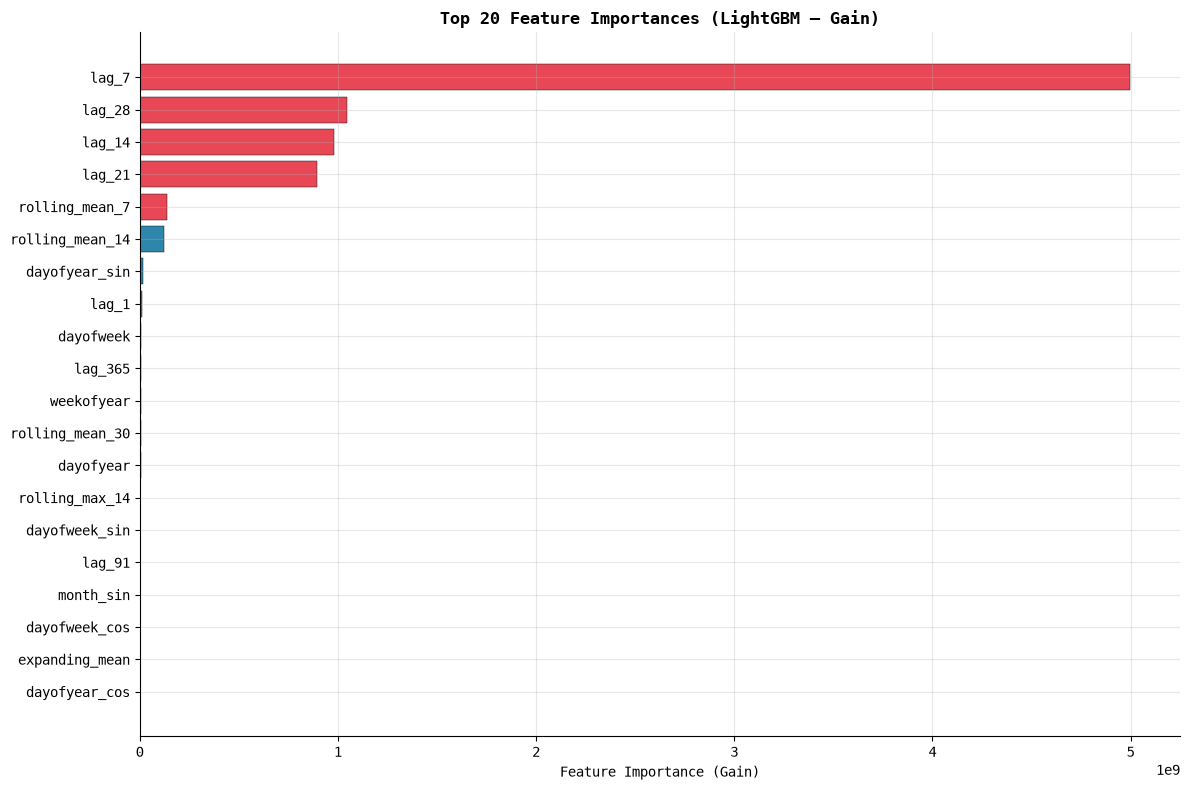

In [7]:
# Feature Importance
importance_df = pd.DataFrame({
    'feature': model.feature_name(),
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#E84855' if i < 5 else '#2E86AB' for i in range(len(importance_df))]
ax.barh(importance_df['feature'][::-1], importance_df['importance'][::-1],
        color=colors[::-1], edgecolor='black', linewidth=0.3)
ax.set_title('Top 20 Feature Importances (LightGBM — Gain)', fontweight='bold')
ax.set_xlabel('Feature Importance (Gain)')
plt.tight_layout()
plt.savefig('../outputs/plots/06_feature_importance.png', dpi=150)
plt.show()

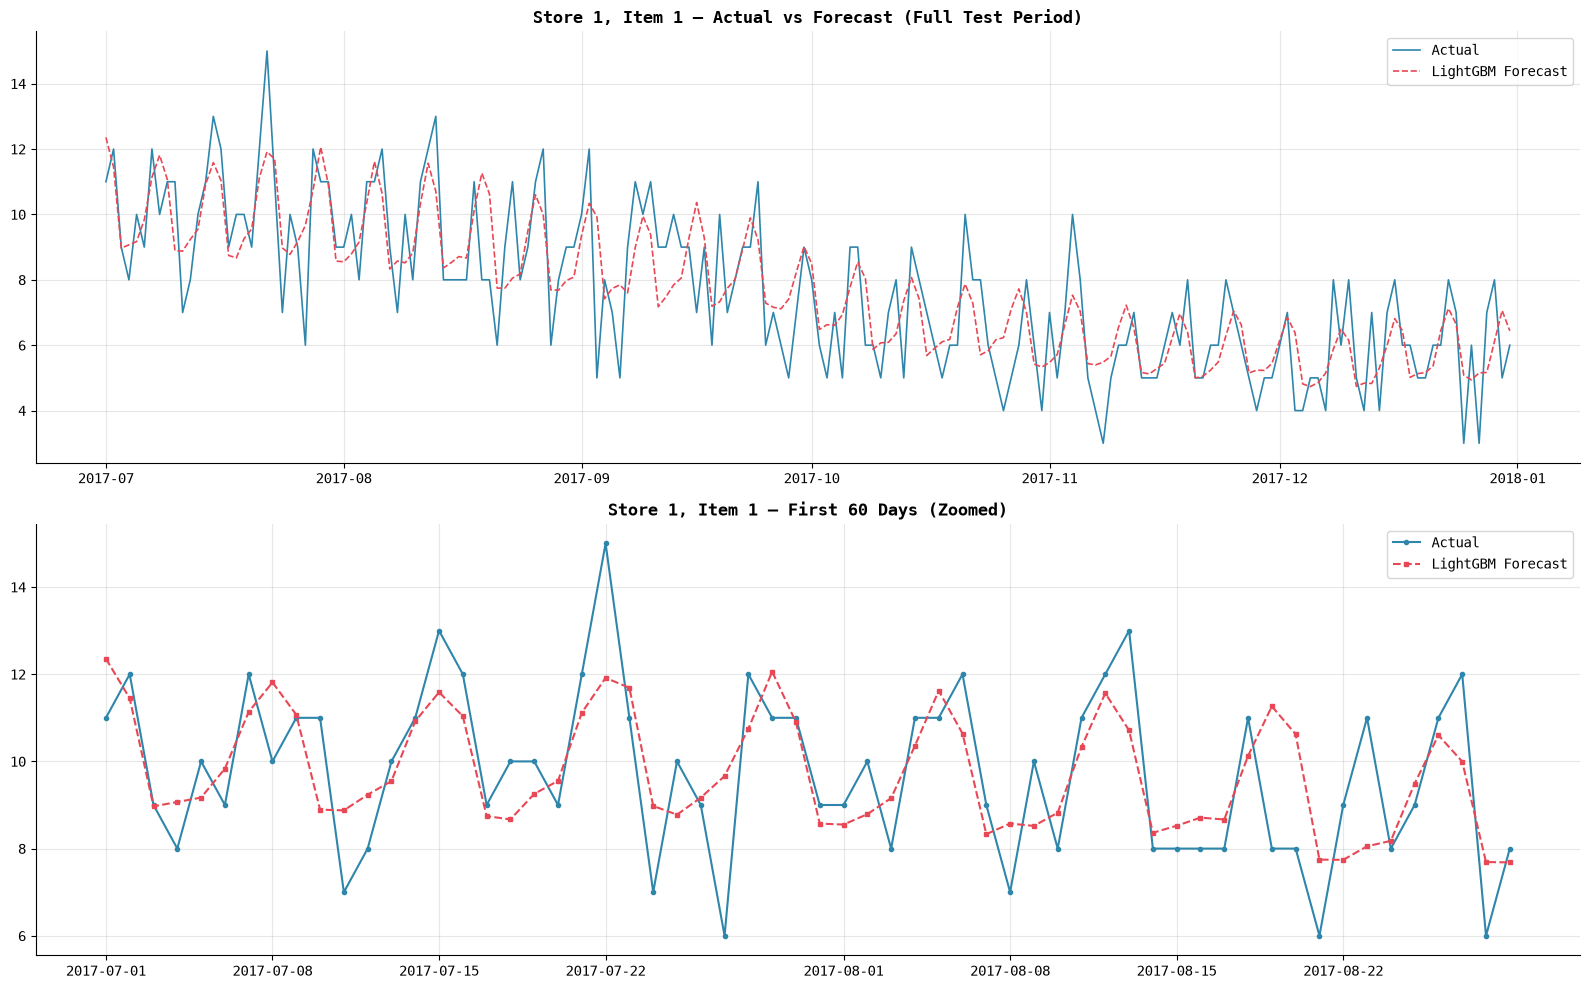

In [8]:
# Actual vs Predicted Plot
s, i = 1, 1
mask = (test['store'] == s) & (test['item'] == i)
test_sub  = test[mask]
actual    = y_test[mask].values
predicted = lgb_preds[mask.values]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
axes[0].plot(test_sub['date'], actual, label='Actual', color='#2E86AB', linewidth=1.2)
axes[0].plot(test_sub['date'], predicted, label='LightGBM Forecast', color='#E84855', linewidth=1.2, linestyle='--')
axes[0].set_title(f'Store {s}, Item {i} — Actual vs Forecast (Full Test Period)', fontweight='bold')
axes[0].legend()

axes[1].plot(test_sub['date'][:60], actual[:60], label='Actual', color='#2E86AB', linewidth=1.5, marker='o', markersize=3)
axes[1].plot(test_sub['date'][:60], predicted[:60], label='LightGBM Forecast', color='#E84855', linewidth=1.5, linestyle='--', marker='s', markersize=3)
axes[1].set_title(f'Store {s}, Item {i} — First 60 Days (Zoomed)', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig('../outputs/plots/07_actual_vs_predicted.png', dpi=150)
plt.show()

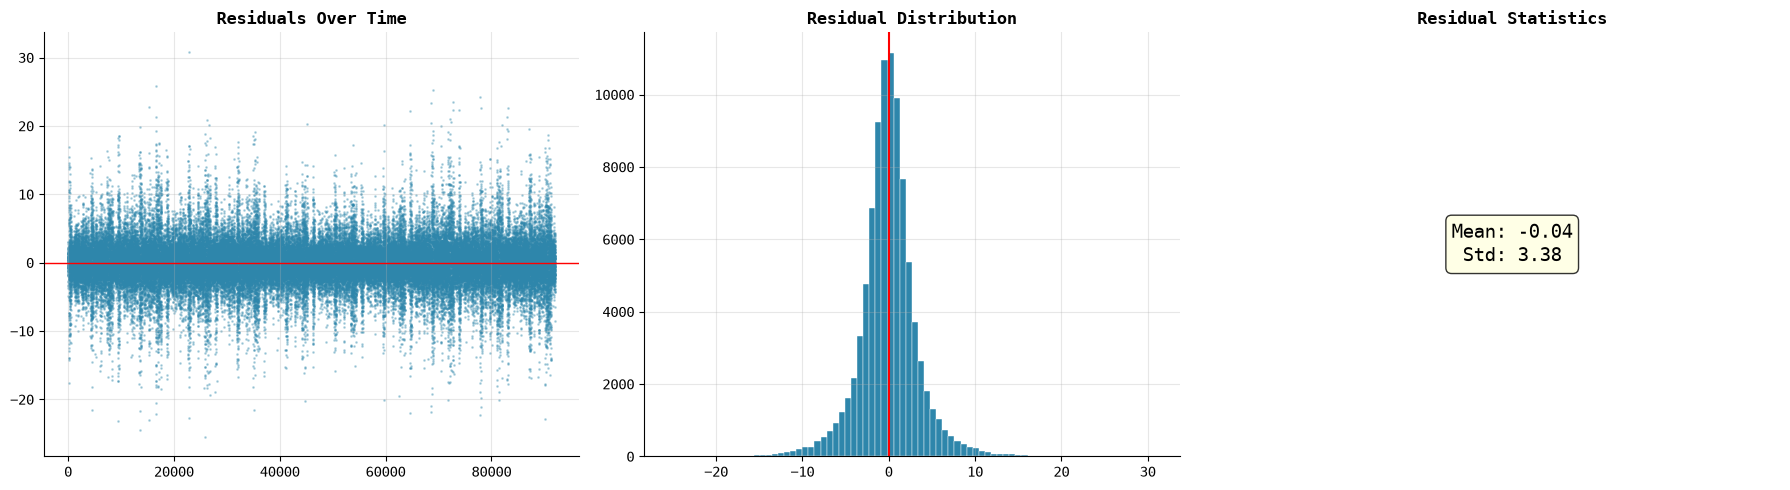

In [9]:
# Residual Analysis
residuals = y_test.values - lgb_preds
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(range(len(residuals)), residuals, alpha=0.3, s=1, color='#2E86AB')
axes[0].axhline(0, color='red', linewidth=1)
axes[0].set_title('Residuals Over Time', fontweight='bold')

axes[1].hist(residuals, bins=80, color='#2E86AB', edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='red', linewidth=1.5)
axes[1].set_title('Residual Distribution', fontweight='bold')

mean_res = np.mean(residuals)
std_res  = np.std(residuals)
axes[2].text(0.5, 0.5, f'Mean: {mean_res:.2f}\nStd: {std_res:.2f}', transform=axes[2].transAxes, fontsize=14,
             verticalalignment='center', horizontalalignment='center', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[2].set_title('Residual Statistics', fontweight='bold')
axes[2].axis('off')
plt.tight_layout()
plt.savefig('../outputs/plots/08_residual_analysis.png', dpi=150)
plt.show()

In [10]:
# Walk-Forward Backtesting
from src.evaluate import run_backtest

cutoff_dates = ['2016-07-01', '2016-10-01', '2017-01-01', '2017-04-01']
backtest_results = run_backtest(df, FEATURE_COLS, TARGET, cutoff_dates, params)
backtest_results.to_csv('../outputs/results/backtest_results.csv', index=False)
print(backtest_results)

       cutoff  test_days  mape_model  mape_baseline  rmse_model  \
0  2016-07-01         90       9.597         13.313       3.531   
1  2016-10-01         90      11.753         16.133       2.882   
2  2017-01-01         90      11.192         14.903       3.049   
3  2017-04-01         90       8.921         11.930       3.848   

   rmse_baseline  improvement_pct  
0          4.911             27.9  
1          4.116             27.1  
2          4.424             24.9  
3          5.247             25.2  


Generating prediction intervals...


90% Prediction Interval Coverage: 84.9%


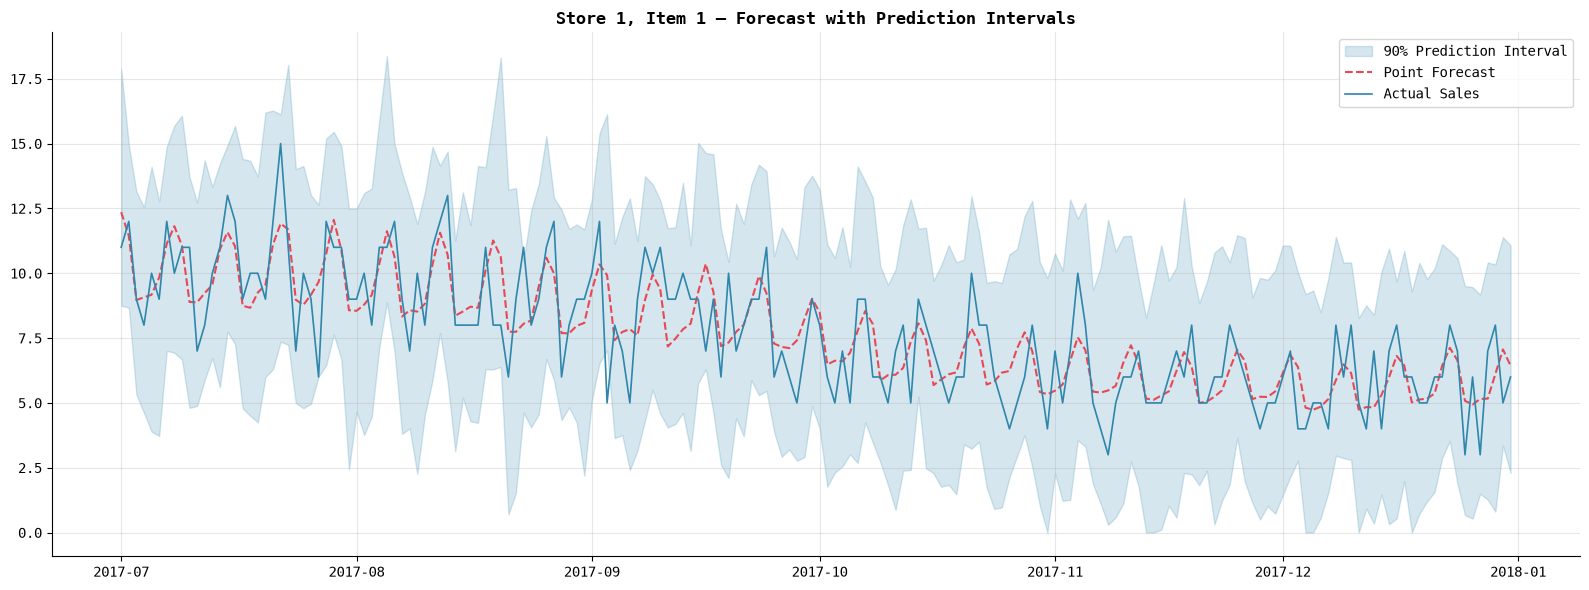

In [11]:
# Prediction Intervals (Residual Bootstrap)
from src.model import bootstrap_prediction_intervals

print("Generating prediction intervals...")
lower, upper, point = bootstrap_prediction_intervals(model, X_test, train_residuals, best_iteration)
coverage = np.mean((y_test.values >= lower) & (y_test.values <= upper)) * 100
print(f"90% Prediction Interval Coverage: {coverage:.1f}%")

# Plot Store 1 Item 1 with intervals
fig, ax = plt.subplots(figsize=(16, 6))
dates = test[mask]['date']
ax.fill_between(dates, lower[mask.values], upper[mask.values], alpha=0.2, color='#2E86AB', label='90% Prediction Interval')
ax.plot(dates, point[mask.values], color='#E84855', linewidth=1.5, linestyle='--', label='Point Forecast')
ax.plot(dates, y_test.values[mask.values], color='#2E86AB', linewidth=1.2, label='Actual Sales')
ax.set_title('Store 1, Item 1 — Forecast with Prediction Intervals', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/plots/10_prediction_intervals.png', dpi=150)
plt.show()